# Do nontidal (upstream) data improve prediction of tidal Enterococcus?
### Section 2: Blue Water Baltimore AWQMP, 2013-2024

This continues the Section 1 rainfall and streamflow work and looks at one question: does adding nontidal data help predict Enterococcus at the tidal harbor?

The target is Enterococcus at the tidal harbor stations (BWB-PATMH, Patapsco). I start from a model that uses only the harbor's own measurements, then add the upstream stream conditions from Gwynns Falls (BWB-GWN) and Jones Falls (BWB-JON), which drain into the harbor. Everything is compared on the same samples and the same year-blocked folds.

| Set | Contents | Question |
|---|---|---|
| T1 (base) | season, location, site, harbor in-situ water quality (chem panel and surface sonde) | harbor-only baseline |
| T2 (+ nontidal) | T1 plus upstream stream Enterococcus, turbidity, TP, DO, nitrate, conductance, temperature | does upstream data help? |
| T3 (nontidal only) | season, location, upstream stream data (no harbor chemistry) | can upstream data alone predict the harbor? |

Short answer: yes. Adding upstream data raises cross-validated R2 from 0.165 to 0.278 and exceedance AUC from 0.746 to 0.802 on matched samples, and the added block is significant (partial-F p<0.001, LR chi2 p<0.001). The strongest single upstream predictor is the streams' own Enterococcus, which fits the idea that the streams carry bacteria into the harbor.

## 1. Setup

Put the workbook in ./data/ and edit XL if the filename differs. The USGS daily discharge series is not available yet, so the streamflow section (Section 11) is written but not run.

In [1]:
import warnings, numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (r2_score, mean_squared_error, roc_auc_score,
                             average_precision_score, roc_curve)
from pathlib import Path

XL      = Path('data') / 'BWB_AWQMP_Data_2009-2024-analyse061026.xlsx'
THRESH  = 104.0     # single-sample recreational exceedance, MPN/100 mL
JOIN_TOL = 7        # days: match a harbor sample to the nearest stream survey within +/- this window
RANDOM_STATE = 42
HARBOR, STREAM, NEUTRAL, SITE = '#2a78d6', '#e6602c', '#b7c3bd', '#7c8a85'
plt.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':.25,'axes.axisbelow':True,'figure.facecolor':'white','axes.facecolor':'white'})
print('workbook present:', XL.exists())

workbook present: True


## 2. Load and harmonize the Enterococcus target

Same as Section 1: one value per sample, using the A2LA lab where available and otherwise converting the BWB lab value with $\log_{10}(A2LA+1) = -0.0424 + 0.7830\,\log_{10}(BWB+1)$. Censored results are mapped to their limits (values below 10 to half the limit, above 24196 to the limit).

In [2]:
def clean_bacteria(s):
    def f(v):
        if pd.isna(v): return np.nan
        if isinstance(v,(int,float)): return float(v)
        t=str(v).strip().replace(',','')
        if t.startswith('<'): return float(t[1:])/2.0
        if t.startswith('>'): return float(t[1:])
        try: return float(t)
        except: return np.nan
    return s.map(f)

def to_date(s):
    if np.issubdtype(s.dtype, np.number):
        return pd.to_datetime(s, unit='D', origin='1899-12-30').dt.normalize()
    return pd.to_datetime(s, errors='coerce').dt.normalize()

def harmonize(a,b):
    b_equiv = 10**(-0.0424 + 0.7830*np.log10(b+1)) - 1
    return a.where(a.notna(), b_equiv)

def load_sheet(sheet):
    df = pd.read_excel(XL, sheet_name=sheet)
    df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]
    df['date']   = to_date(df['Collection Date'])
    df['prefix'] = df['Station ID'].astype(str).str.extract(r'(BWB-[A-Z]+)')
    a = clean_bacteria(df['Enterococcus Bacteria (MPN/100mL) - A2LA Lab'])
    b = clean_bacteria(df['Enterococcus Bacteria (MPN/100mL) - BWB Lab'])
    df['entero'] = harmonize(a,b)
    return df

tidal = load_sheet('BWB Tidal Data 2009-2024')
nt    = load_sheet('BWB Nontidal Data 2013-2024')
print('tidal harbor samples w/ target :', tidal['entero'].notna().sum())
print('nontidal stream samples w/ target:', nt['entero'].notna().sum(),
      '| GWN', (nt['prefix']=='BWB-GWN').sum(), 'JON', (nt['prefix']=='BWB-JON').sum())

tidal harbor samples w/ target : 3581
nontidal stream samples w/ target: 3561 | GWN 1923 JON 1800


## 3. Add the harbor surface sonde readings

The tidal data sheet does not include temperature, conductance or DO, but the Tidal Profiles sheet does. I take the shallowest reading per station and date and merge it in, so the harbor baseline uses the full set of harbor measurements and the comparison with the upstream data is fair.

In [3]:
tp = pd.read_excel(XL, sheet_name='BWB Tidal Profiles 2013-2024')
tp['date'] = to_date(tp['Collection Date'])
prof_cols = ['Temperature (\u00b0C)','pH (SU)','Specific Conductance (\u00b5S/cm)','Salinity (ppt)','Dissolved Oxygen (mg/L)']
surf = (tp.sort_values('Reading Depth (m)')
          .groupby(['Station ID','date'], as_index=False).first()[['Station ID','date']+prof_cols])
tidal = tidal.merge(surf, on=['Station ID','date'], how='left')
print('harbor samples matched to a surface profile:', tidal['Temperature (\u00b0C)'].notna().mean().round(2))

harbor samples matched to a surface profile: 0.67


## 4. Build the upstream stream conditions

For each date the streams were sampled, I summarize the network into a few daily numbers: pooled mean and max log Enterococcus and mean chemistry (ntALL_*), plus stream Enterococcus for each watershed separately (ntGWN_*, ntJON_*). These are the upstream predictors I test.

In [4]:
NT_CHEM = {'Turbidity (NTU)':'turb','Total Phosphorus (mg/L)':'tp','Dissolved Oxygen (mg/L)':'do',
           'Nitrate/Nitrite (mg/L)':'no23','Specific Conductance (\u00b5S/cm)':'cond','Temperature (\u00b0C)':'temp'}
ntw = nt.copy(); ntw['log_entero'] = np.log10(ntw['entero']+1)
for c in NT_CHEM: ntw[c] = pd.to_numeric(ntw[c], errors='coerce')

def daily_agg(df, label):
    g = df.groupby('date')
    out = pd.DataFrame({f'{label}_entero_mean':g['log_entero'].mean(),
                        f'{label}_entero_max' :g['log_entero'].max()})
    for c,short in NT_CHEM.items(): out[f'{label}_{short}'] = g[c].mean()
    return out.reset_index()

agg_all = daily_agg(ntw, 'ntALL')
agg_gwn = daily_agg(ntw[ntw['prefix']=='BWB-GWN'],'ntGWN')[['date','ntGWN_entero_mean','ntGWN_entero_max']]
agg_jon = daily_agg(ntw[ntw['prefix']=='BWB-JON'],'ntJON')[['date','ntJON_entero_mean','ntJON_entero_max']]
nt_daily = (agg_all.merge(agg_gwn,on='date',how='outer').merge(agg_jon,on='date',how='outer').sort_values('date'))
NT_FEATURES = [c for c in nt_daily.columns if c!='date']
print(len(NT_FEATURES),'nontidal features:', NT_FEATURES)

12 nontidal features: ['ntALL_entero_mean', 'ntALL_entero_max', 'ntALL_turb', 'ntALL_tp', 'ntALL_do', 'ntALL_no23', 'ntALL_cond', 'ntALL_temp', 'ntGWN_entero_mean', 'ntGWN_entero_max', 'ntJON_entero_mean', 'ntJON_entero_max']


## 5. Match the upstream conditions to each harbor sample

The harbor and the streams are sampled on their own schedules and rarely on the exact same day, but the nearest stream survey is within 1 day for the median harbor sample and within 7 days for about 87% of them. I attach the nearest stream reading within 7 days using merge_asof. I also keep a backward-only version (streams on or before the harbor date) as a check.

In [5]:
tidal = tidal.sort_values('date')
merged = pd.merge_asof(tidal, nt_daily.rename(columns={'date':'nt_date'}),
                       left_on='date', right_on='nt_date', direction='nearest',
                       tolerance=pd.Timedelta(f'{JOIN_TOL}D'))
merged['nt_lag_days'] = (merged['date']-merged['nt_date']).dt.days
merged['has_nt']      = merged['ntALL_entero_mean'].notna()

# add season/site context
def add_context(df):
    df = df.copy(); df['month']=df['date'].dt.month
    df['msin']=np.sin(2*np.pi*df['month']/12); df['mcos']=np.cos(2*np.pi*df['month']/12)
    df['year']=df['date'].dt.year
    for st in sorted(df['Station ID'].astype(str).unique()):
        df[f'site_{st}']=(df['Station ID'].astype(str)==st).astype(int)
    return df
merged = add_context(merged)
sub = merged[merged['has_nt']].copy()   # harbor samples WITH an upstream match

d = merged[merged['entero'].notna()]
print(f'harbor samples: {len(d)} | with upstream match (\u00b1{JOIN_TOL}d): {d["has_nt"].mean():.1%}',
      f'| median |lag| = {d.loc[d["has_nt"],"nt_lag_days"].abs().median():.0f} d')

harbor samples: 3581 | with upstream match (±7d): 87.2% | median |lag| = 1 d


## 6. Feature sets and the cross-validation setup

Whole calendar years are held out (GroupKFold by year) so no sampling week appears in both train and test, the same guard used in Section 1. Each feature set is scored on two tasks over the same folds: regression of $\log_{10}(Entero+1)$ (R2, RMSE) and exceedance above 104 (ROC-AUC, PR-AUC). Missing predictors are filled with the training-fold median.

In [6]:
CONTEXT = ['msin','mcos','Latitude','Longitude']
TIDAL_INSITU = ['Total Water Depth (ft)','Nitrate/Nitrite (mg/L)','Total Nitrogen (mg/L)','Total Phosphorus (mg/L)',
                'Total Kjeldahl Nitrogen (mg/L)','Chlorophyll (\u00b5g/L)','Secchi Depth (m)'] + prof_cols

def feature_sets():
    return {'T0 Context':            CONTEXT,
            'T1 + Harbor in-situ WQ':CONTEXT + TIDAL_INSITU,
            'T2 + Nontidal data':    CONTEXT + TIDAL_INSITU + NT_FEATURES,
            'T3 Nontidal only':      CONTEXT + NT_FEATURES}

def evaluate(df, feats, model='rf', n_splits=5, seed=RANDOM_STATE):
    d = df[df['entero'].notna()].copy()
    site_cols = [c for c in d.columns if c.startswith('site_')]
    cols = feats + site_cols
    X = d[cols].apply(lambda c: pd.to_numeric(c, errors='coerce')).astype(float).values
    y_reg = np.log10(d['entero'].values + 1.0)
    y_cls = (d['entero'].values > THRESH).astype(int)
    groups = d['year'].values
    def make(kind):
        if model=='rf':
            reg=RandomForestRegressor(300,min_samples_leaf=3,n_jobs=-1,random_state=seed)
            clf=RandomForestClassifier(300,min_samples_leaf=3,n_jobs=-1,random_state=seed,class_weight='balanced')
        else:
            reg=GradientBoostingRegressor(random_state=seed); clf=GradientBoostingClassifier(random_state=seed)
        return reg if kind=='reg' else clf
    gkf=GroupKFold(n_splits=n_splits); oof_reg=np.full(len(d),np.nan); oof_p=np.full(len(d),np.nan)
    for tr,te in gkf.split(X,y_reg,groups):
        med=np.nanmedian(X[tr],axis=0); med=np.where(np.isnan(med),0,med)
        Xtr=np.where(np.isnan(X[tr]),med,X[tr]); Xte=np.where(np.isnan(X[te]),med,X[te])
        oof_reg[te]=make('reg').fit(Xtr,y_reg[tr]).predict(Xte)
        oof_p[te]  =make('clf').fit(Xtr,y_cls[tr]).predict_proba(Xte)[:,1]
    return dict(R2=r2_score(y_reg,oof_reg), RMSE=np.sqrt(mean_squared_error(y_reg,oof_reg)),
                AUC=roc_auc_score(y_cls,oof_p), PR_AUC=average_precision_score(y_cls,oof_p),
                n=len(d), exc=y_cls.mean(), y_cls=y_cls, oof_p=oof_p)

## 7. Main result: nested comparison

Two views are shown. First the matched subset, the harbor samples that have an upstream survey within 7 days, which answers whether upstream data help when they exist. Second the full harbor sample, where unmatched rows keep an imputed upstream block so the sample size and folds match across sets; this understates the effect but keeps everything comparable.

In [7]:
def comparison(df, model='rf'):
    rows = {n: evaluate(df, f, model=model) for n,f in feature_sets().items()}
    tab = pd.DataFrame({k:{'R\u00b2':v['R2'],'RMSE':v['RMSE'],'AUC':v['AUC'],'PR-AUC':v['PR_AUC']}
                        for k,v in rows.items()}).T.round(3)
    return tab, rows

tab_sub, res_sub = comparison(sub)
print(f'MATCHED SUBSET  n={res_sub["T1 + Harbor in-situ WQ"]["n"]}  '
      f'exceedance base rate {res_sub["T1 + Harbor in-situ WQ"]["exc"]:.1%}')
display(tab_sub)
b,a = tab_sub.loc['T1 + Harbor in-situ WQ'], tab_sub.loc['T2 + Nontidal data']
print('Nontidal lift (T2 - T1):', dict((a-b).round(3)))

tab_full, res_full = comparison(merged)
print(f'\nFULL SAMPLE     n={res_full["T1 + Harbor in-situ WQ"]["n"]}  '
      f'exceedance base rate {res_full["T1 + Harbor in-situ WQ"]["exc"]:.1%}')
display(tab_full)
b,a = tab_full.loc['T1 + Harbor in-situ WQ'], tab_full.loc['T2 + Nontidal data']
print('Nontidal lift (T2 - T1):', dict((a-b).round(3)))

MATCHED SUBSET  n=3121  exceedance base rate 16.6%


,R²,RMSE,AUC,PR-AUC
T0 Context,0.139,0.918,0.712,0.332
T1 + Harbor in-situ WQ,0.165,0.904,0.746,0.357
T2 + Nontidal data,0.278,0.841,0.802,0.496
T3 Nontidal only,0.224,0.872,0.788,0.450


Nontidal lift (T2 - T1): {'R²': np.float64(0.113), 'RMSE': np.float64(-0.063), 'AUC': np.float64(0.056), 'PR-AUC': np.float64(0.139)}



FULL SAMPLE     n=3581  exceedance base rate 16.1%


,R²,RMSE,AUC,PR-AUC
T0 Context,0.171,0.903,0.710,0.320
T1 + Harbor in-situ WQ,0.204,0.885,0.745,0.356
T2 + Nontidal data,0.228,0.872,0.798,0.477
T3 Nontidal only,0.163,0.908,0.792,0.441


Nontidal lift (T2 - T1): {'R²': np.float64(0.024), 'RMSE': np.float64(-0.013), 'AUC': np.float64(0.053), 'PR-AUC': np.float64(0.121)}


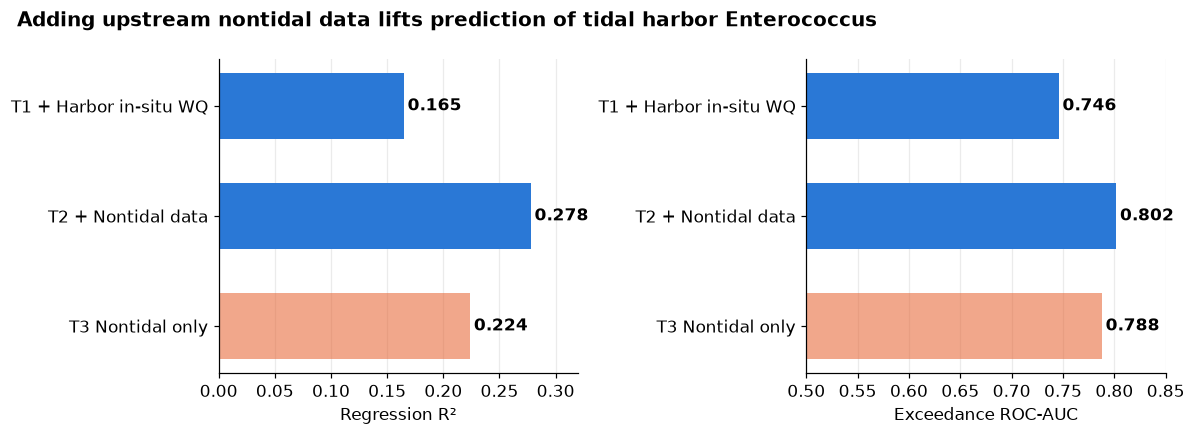

In [8]:
# ---- visualize the comparison (matched subset) ----
order=['T1 + Harbor in-situ WQ','T2 + Nontidal data','T3 Nontidal only']
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,metric,lo,hi,lab in [(axes[0],'R\u00b2',0,0.32,'Regression R\u00b2'),
                            (axes[1],'AUC',0.5,0.85,'Exceedance ROC-AUC')]:
    vals=tab_sub.loc[order,metric]
    for i,(k,v) in enumerate(vals.items()):
        c=HARBOR if k!='T3 Nontidal only' else STREAM
        ax.barh(i,v,color=c,alpha=[1,1,.55][i],height=.6)
        ax.text(v+(hi-lo)*.01,i,f'{v:.3f}',va='center',fontweight='bold')
    ax.set_yticks(range(3)); ax.set_yticklabels(order); ax.invert_yaxis()
    ax.set_xlim(lo,hi); ax.set_xlabel(lab); ax.grid(axis='y',alpha=0)
fig.suptitle('Adding upstream nontidal data lifts prediction of tidal harbor Enterococcus',
             x=.02,ha='left',fontweight='bold'); plt.tight_layout(); plt.show()

## 8. Dose-response: harbor exceedance vs upstream bacteria

Grouping harbor samples by the same-week upstream stream Enterococcus and plotting the share above 104 shows a steady rise, which is the simple reason the upstream data help.

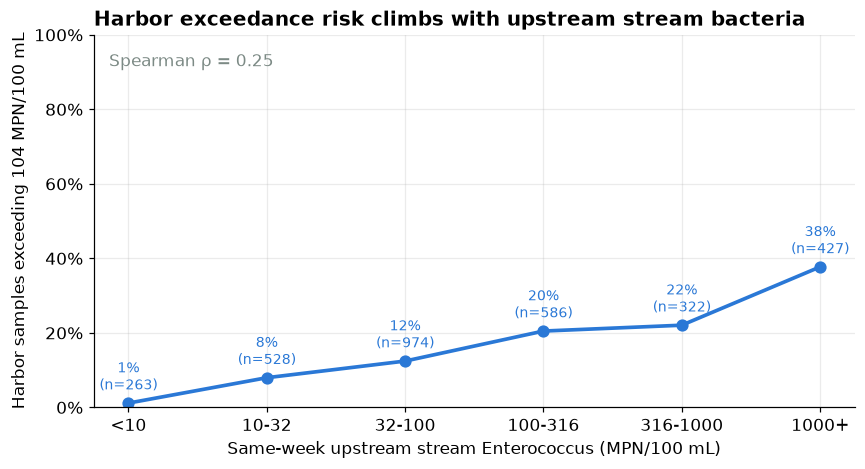

In [9]:
dd = sub[sub['entero'].notna()].copy(); dd['exc']=(dd['entero']>THRESH).astype(int)
dd['up']=pd.to_numeric(dd['ntALL_entero_mean'],errors='coerce')
bins=[0,1,1.5,2,2.5,3,5]; labs=['<10','10-32','32-100','100-316','316-1000','1000+']
dd['b']=pd.cut(dd['up'],bins=bins,labels=labs)
g=dd.groupby('b',observed=True)['exc'].agg(['mean','count'])
fig,ax=plt.subplots(figsize=(8,4.4))
ax.plot(range(len(g)),g['mean']*100,'-o',color=HARBOR,lw=2.4,ms=7)
for i,(m,n) in enumerate(zip(g['mean'],g['count'])):
    ax.annotate(f'{m*100:.0f}%\n(n={n})',(i,m*100),textcoords='offset points',xytext=(0,9),ha='center',fontsize=9,color=HARBOR)
ax.set_xticks(range(len(g))); ax.set_xticklabels(list(g.index)); ax.set_ylim(0,100)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel('Harbor samples exceeding 104 MPN/100 mL'); ax.set_xlabel('Same-week upstream stream Enterococcus (MPN/100 mL)')
ax.set_title('Harbor exceedance risk climbs with upstream stream bacteria',loc='left',fontweight='bold')
rho=stats.spearmanr(dd['up'],np.log10(dd['entero']+1),nan_policy='omit').correlation
ax.text(0.02,0.95,f'Spearman \u03c1 = {rho:.2f}',transform=ax.transAxes,va='top',color=SITE); plt.tight_layout(); plt.show()

## 9. Which upstream variables matter?

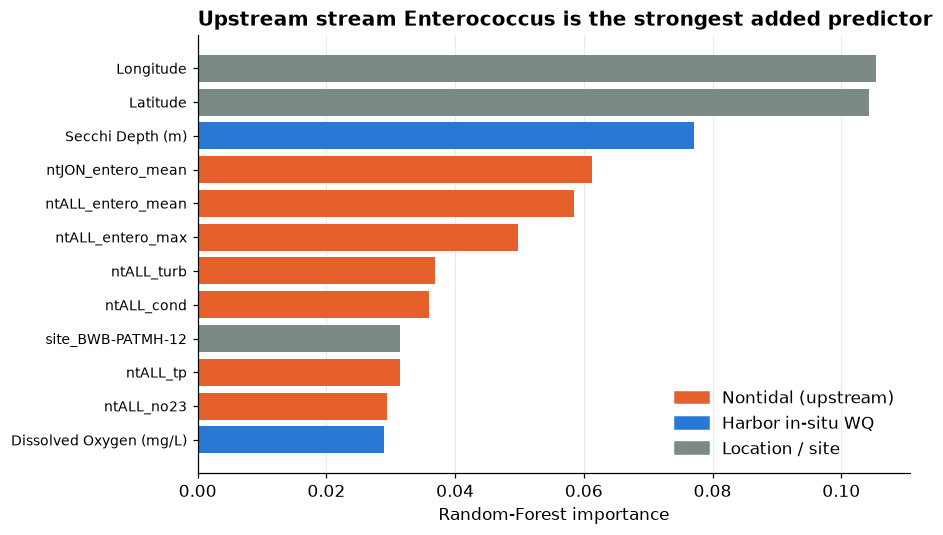

In [10]:
d=sub[sub['entero'].notna()].copy(); site_cols=[c for c in d.columns if c.startswith('site_')]
cols=feature_sets()['T2 + Nontidal data']+site_cols
X=d[cols].apply(lambda c:pd.to_numeric(c,errors='coerce')).astype(float); X=X.fillna(X.median())
rf=RandomForestRegressor(400,min_samples_leaf=3,n_jobs=-1,random_state=0).fit(X,np.log10(d['entero']+1))
imp=pd.Series(rf.feature_importances_,index=cols).sort_values(ascending=False).head(12)[::-1]
kind=lambda n: STREAM if n in NT_FEATURES else (SITE if (n.startswith('site_') or n in ('Latitude','Longitude')) else HARBOR)
fig,ax=plt.subplots(figsize=(8.5,5)); ax.barh(range(len(imp)),imp.values,color=[kind(i) for i in imp.index])
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index,fontsize=9); ax.grid(axis='y',alpha=0)
ax.set_xlabel('Random-Forest importance'); ax.set_title('Upstream stream Enterococcus is the strongest added predictor',loc='left',fontweight='bold')
ax.legend(handles=[Patch(color=STREAM,label='Nontidal (upstream)'),Patch(color=HARBOR,label='Harbor in-situ WQ'),
                   Patch(color=SITE,label='Location / site')],frameon=False,loc='lower right'); plt.tight_layout(); plt.show()

## 10. Formal test and robustness

A linear and logistic nested test with year fixed effects gives a p-value for the whole upstream block. The cross-validated lift is then rechecked across random seeds and with a Gradient Boosting model.

In [11]:
d=sub[sub['entero'].notna()].copy()
base_num=list(CONTEXT+TIDAL_INSITU); add_num=list(NT_FEATURES)
for c in base_num+add_num: d[c]=pd.to_numeric(d[c],errors='coerce')
d[base_num+add_num]=d[base_num+add_num].fillna(d[base_num+add_num].median())
yearFE=pd.get_dummies(d['year'].astype(int),prefix='yr',drop_first=True).astype(float)
ylog=np.log10(d['entero']+1).values; yexc=(d['entero']>THRESH).astype(int).values
Xb=sm.add_constant(pd.concat([d[base_num].reset_index(drop=True),yearFE.reset_index(drop=True)],axis=1).astype(float))
Xf=sm.add_constant(pd.concat([d[base_num+add_num].reset_index(drop=True),yearFE.reset_index(drop=True)],axis=1).astype(float))
q=len(add_num)
mb=sm.OLS(ylog,Xb).fit(); mf=sm.OLS(ylog,Xf).fit(); dfd=int(mf.df_resid)
F=((mb.ssr-mf.ssr)/q)/(mf.ssr/dfd); pF=1-stats.f.cdf(F,q,dfd)
print(f'OLS  log10(Entero): adjR\u00b2 {mb.rsquared_adj:.3f} -> {mf.rsquared_adj:.3f} | partial-F({q},{dfd})={F:.1f}  p={pF:.2g}')
lb=sm.Logit(yexc,Xb).fit(disp=0); lf=sm.Logit(yexc,Xf).fit(disp=0)
LR=2*(lf.llf-lb.llf); pLR=1-stats.chi2.cdf(LR,q)
print(f'Logit exceed>104 : pseudoR\u00b2 {lb.prsquared:.3f} -> {lf.prsquared:.3f} | LR \u03c7\u00b2({q})={LR:.0f}  p={pLR:.2g}')

fs=feature_sets()
for model in ['rf','gb']:
    dr=[da for da in []]; dr=[]; da=[]
    for s in (0,1,2):
        bb=evaluate(sub,fs['T1 + Harbor in-situ WQ'],model=model,seed=s)
        aa=evaluate(sub,fs['T2 + Nontidal data'],model=model,seed=s)
        dr.append(aa['R2']-bb['R2']); da.append(aa['AUC']-bb['AUC'])
    print(f'{model.upper()}: \u0394R\u00b2={np.mean(dr):+.3f}\u00b1{np.std(dr):.3f}  \u0394AUC={np.mean(da):+.3f}\u00b1{np.std(da):.3f}')

OLS  log10(Entero): adjR² 0.335 -> 0.386 | partial-F(12,3081)=22.4  p=0


Logit exceed>104 : pseudoR² 0.273 -> 0.344 | LR χ²(12)=200  p=0


RF: ΔR²=+0.116±0.001  ΔAUC=+0.057±0.001


GB: ΔR²=+0.072±0.001  ΔAUC=+0.057±0.001


## 11. Streamflow section (waiting on daily USGS data)

The file usgs_daily_mean_discharge_clean_combined.csv is still a 3-row per-gauge summary (min, median, max), not the daily values it refers to. Once the daily series is available (columns site_no, date, discharge_cfs for 01589300 Gwynns and 01589440 Jones), the code below builds antecedent-flow features and adds them to the upstream set to test whether discharge adds anything on top of stream chemistry. Herring Run (01585219) has no bacteria stations, so it could only be used as a basin-wide flow index.

In [12]:
GAUGE_TO_WS = {1589300:'Gwynns', 1589440:'Jones'}
STREAMFLOW_DAILY = None   # <- set to the daily CSV path when available

def build_flow_features(daily):
    daily=daily.copy(); daily['date']=pd.to_datetime(daily['date']).dt.normalize()
    parts=[]
    for sid,g in daily.groupby('site_no'):
        g=g.sort_values('date').set_index('date'); q=pd.to_numeric(g['discharge_cfs'],errors='coerce')
        idx=pd.date_range(q.index.min(),q.index.max(),freq='D'); q=q.reindex(idx).interpolate()
        f=pd.DataFrame(index=idx)
        f['q_0d']=q; f['q_1d']=q.shift(1); f['q_3d']=q.rolling(3).mean().shift(1)
        f['q_7d']=q.rolling(7).mean().shift(1); f['logq']=np.log10(q+1); f['q_rise']=q-q.shift(1)
        f=f.add_prefix(f'flow{int(sid)}_').reset_index(names='date'); parts.append(f)
    from functools import reduce
    return reduce(lambda a,b: a.merge(b,on='date',how='outer'), parts)

def run_with_streamflow(path=STREAMFLOW_DAILY):
    if path is None:
        print('No daily streamflow yet - set STREAMFLOW_DAILY and re-run.'); return
    flow=build_flow_features(pd.read_csv(path))
    m2=pd.merge_asof(merged.sort_values('date'), flow.sort_values('date').rename(columns={'date':'q_date'}),
                     left_on='date',right_on='q_date',direction='nearest',tolerance=pd.Timedelta('3D'))
    FLOW=[c for c in flow.columns if c!='date']
    base=evaluate(m2, feature_sets()['T2 + Nontidal data'])
    full=evaluate(m2, feature_sets()['T2 + Nontidal data']+FLOW)
    print('adding streamflow to the upstream set:')
    print(f'  R2  {base["R2"]:.3f} -> {full["R2"]:.3f}   AUC {base["AUC"]:.3f} -> {full["AUC"]:.3f}')
run_with_streamflow()

No daily streamflow yet - set STREAMFLOW_DAILY and re-run.


## 12. Summary

1. Adding nontidal (upstream) data improves prediction of tidal Enterococcus. On matched harbor samples it raises cross-validated R2 from 0.165 to 0.278 and exceedance AUC from 0.746 to 0.802 over the harbor-only baseline. The added block is significant (OLS partial-F p<0.001, logistic LR chi2 p<0.001) and holds up across seeds and models.

2. Most of the signal is the upstream Enterococcus itself. Jones Falls and the pooled stream mean rank first among the added predictors, with stream turbidity and TP behind them, which fits the streams carrying bacteria into the harbor. Harbor exceedance rises from about 1% when the streams are clean to about 38% when they are high.

3. Upstream data alone (T3) predicts almost as well as the harbor-only baseline (AUC 0.788 vs 0.746), so upstream monitoring is useful even where harbor chemistry is limited.

4. One caveat: upstream bacteria are rain-driven, so some of this improvement may overlap with the antecedent-rainfall signal from Section 1. Adding the NOAA rainfall block to the baseline before comparing T1 and T2 would separate the stream-transport effect from shared weather, and is worth doing when the two analyses are combined.

5. The streamflow test is still waiting on the daily USGS discharge series; Section 11 runs once that data is available.